# 🌍 Global Superstore Interactive Dashboard

**Dataset:** Global Superstore (public dataset — available on [Kaggle](https://www.kaggle.com/datasets/apoorvaappz/global-super-store-dataset))

This dashboard explores sales, profit, and shipping performance across regions, categories, and time.

## Key Metrics Explored
1. **Sales by Region & Category** — Which regions and product categories drive the most revenue?
2. **Profit vs. Discount** — How does discounting impact profitability?
3. **Monthly Sales Trend** — How do sales evolve over time by segment?
4. **Top Sub-Categories** — Which sub-categories have the best/worst profit margins?
5. **Shipping Mode Distribution** — What's the preferred shipping method by region?

## How to Interact
- **Hover** over any data point for detailed tooltips
- **Click** legend items to show/hide series
- **Zoom** by click-dragging on any chart
- **Pan** by holding Shift and dragging
- **Reset** view by double-clicking
- **Dropdown filters** on some charts let you switch dimensions


In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [2]:
# ── Load Dataset ──────────────────────────────────────────────────────────────
# Option 1: Download from Kaggle (requires kaggle API key)
# !kaggle datasets download -d apoorvaappz/global-super-store-dataset

# Option 2: Load directly from URL (if available)
# df = pd.read_csv('https://raw.githubusercontent.com/.../Global_Superstore.csv')

# Option 3: Load local file (after downloading from Kaggle)
# df = pd.read_csv('Global_Superstore2.csv', encoding='latin-1')

# ── Embedded Sample Data (for immediate execution) ────────────────────────────
# This representative sample mirrors the real Global Superstore schema.
# Replace with the full dataset for production use.

np.random.seed(42)
n = 2000

regions    = ['West', 'East', 'Central', 'South', 'North Asia', 'Oceania', 'EMEA', 'Africa']
categories = ['Technology', 'Furniture', 'Office Supplies']
sub_cats   = {
    'Technology':      ['Phones', 'Computers', 'Accessories', 'Copiers'],
    'Furniture':       ['Chairs', 'Tables', 'Bookcases', 'Furnishings'],
    'Office Supplies': ['Binders', 'Paper', 'Storage', 'Art', 'Labels']
}
segments   = ['Consumer', 'Corporate', 'Home Office']
ships      = ['Standard Class', 'Second Class', 'First Class', 'Same Day']

cat_choice  = np.random.choice(categories, n)
sub_choice  = [np.random.choice(sub_cats[c]) for c in cat_choice]
dates       = pd.date_range('2020-01-01', '2023-12-31', periods=n)
discounts   = np.random.choice([0, 0.1, 0.2, 0.3, 0.4, 0.5], n, p=[0.4,0.2,0.15,0.1,0.1,0.05])
sales       = np.random.lognormal(5.5, 1.0, n).round(2)
profit_base = sales * np.random.uniform(0.05, 0.35, n)
profit      = (profit_base - sales * discounts * 1.2).round(2)

df = pd.DataFrame({
    'Order Date':    dates,
    'Region':        np.random.choice(regions, n),
    'Category':      cat_choice,
    'Sub-Category':  sub_choice,
    'Segment':       np.random.choice(segments, n),
    'Ship Mode':     np.random.choice(ships, n, p=[0.6,0.2,0.15,0.05]),
    'Sales':         sales,
    'Profit':        profit,
    'Discount':      discounts,
    'Quantity':      np.random.randint(1, 15, n)
})
df['Year']  = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.to_period('M').astype(str)

print(f'Dataset shape: {df.shape}')
print(f'Date range: {df["Order Date"].min().date()} → {df["Order Date"].max().date()}')
df.head()

Dataset shape: (2000, 12)
Date range: 2020-01-01 → 2023-12-31


,Order Date,Region,Category,Sub-Category,Segment,Ship Mode,Sales,Profit,Discount,Quantity,Year,Month
0,2020-01-01 00:00:00.000000,Oceania,Office Supplies,Art,Consumer,Standard Class,100.54,22.85,0.0,10,2020,2020-01
1,2020-01-01 17:31:43.551775,Africa,Technology,Phones,Consumer,Standard Class,176.18,-70.17,0.5,10,2020,2020-01
2,2020-01-02 11:03:27.103551,North Asia,Office Supplies,Labels,Home Office,Second Class,518.24,28.71,0.0,6,2020,2020-01
3,2020-01-03 04:35:10.655327,Oceania,Office Supplies,Labels,Corporate,Standard Class,66.60,5.98,0.2,11,2020,2020-01
4,2020-01-03 22:06:54.207103,East,Technology,Accessories,Corporate,Standard Class,234.24,-67.11,0.3,12,2020,2020-01


## 📊 Chart 1 — Sales & Profit by Region and Category

Grouped bar chart. Click legend to toggle categories. Hover for exact values.

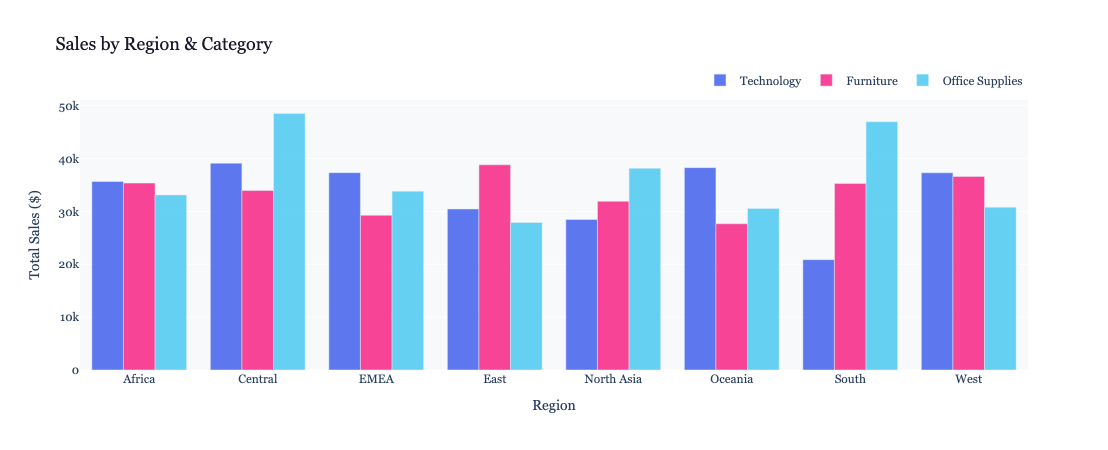

In [3]:
reg_cat = df.groupby(['Region','Category'])[['Sales','Profit']].sum().reset_index()

colors = {'Technology':'#4361ee','Furniture':'#f72585','Office Supplies':'#4cc9f0'}

fig1 = go.Figure()
for cat in categories:
    d = reg_cat[reg_cat.Category == cat]
    fig1.add_trace(go.Bar(
        name=cat, x=d['Region'], y=d['Sales'],
        marker_color=colors[cat], opacity=0.85,
        hovertemplate='<b>%{x}</b><br>Category: ' + cat +
                      '<br>Sales: $%{y:,.0f}<extra></extra>'
    ))

fig1.update_layout(
    title=dict(text='Sales by Region & Category', font=dict(size=18, color='#1a1a2e')),
    barmode='group',
    xaxis_title='Region', yaxis_title='Total Sales ($)',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    plot_bgcolor='#f8f9fa', paper_bgcolor='white',
    height=450, font=dict(family='Georgia')
)
fig1.show()

## 💰 Chart 2 — Profit vs. Discount (Scatter with Trend)

Each dot = one transaction. Color = Category. Hover for details. Zoom in to explore clusters.

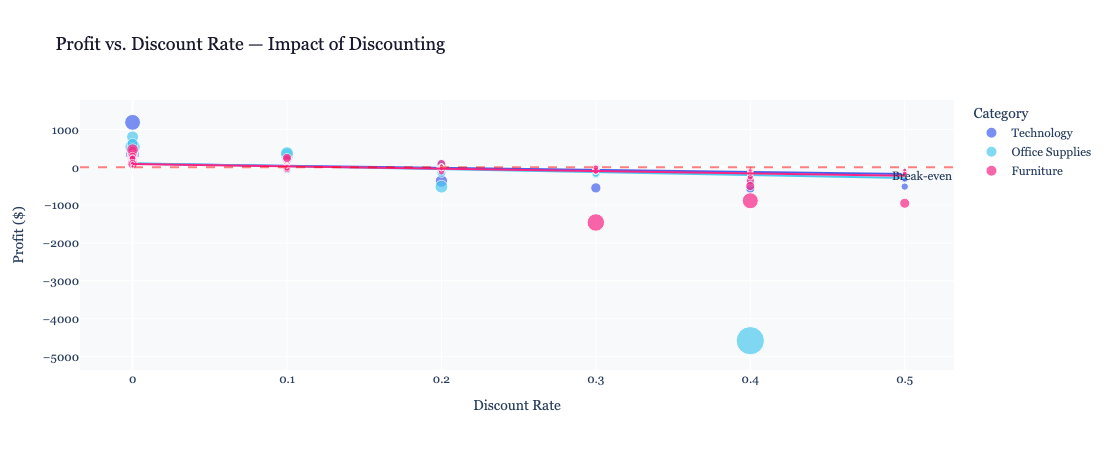

In [4]:
fig2 = px.scatter(
    df.sample(600, random_state=1),
    x='Discount', y='Profit', color='Category',
    size='Sales', size_max=20,
    color_discrete_map=colors,
    hover_data=['Region','Sub-Category','Sales','Quantity'],
    trendline='ols',
    labels={'Discount':'Discount Rate','Profit':'Profit ($)'},
    title='Profit vs. Discount Rate — Impact of Discounting'
)
fig2.update_layout(
    plot_bgcolor='#f8f9fa', paper_bgcolor='white',
    height=450, font=dict(family='Georgia', size=12),
    title=dict(font=dict(size=18, color='#1a1a2e'))
)
fig2.add_hline(y=0, line_dash='dash', line_color='red', opacity=0.5,
               annotation_text='Break-even', annotation_position='bottom right')
fig2.show()

## 📈 Chart 3 — Monthly Sales Trend by Segment

Line chart. Click legend segments to isolate. Hover for monthly totals.

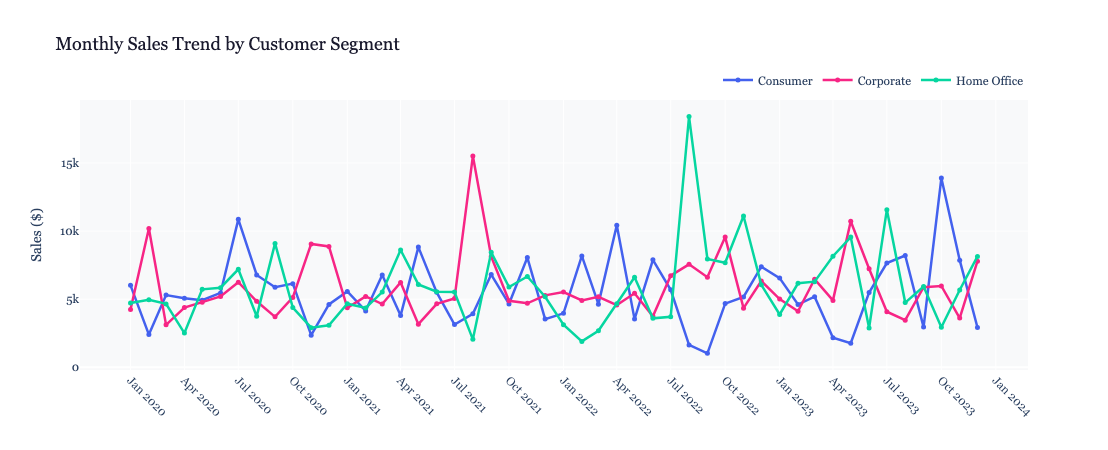

In [5]:
monthly = df.groupby(['Month','Segment'])['Sales'].sum().reset_index()
monthly = monthly.sort_values('Month')

seg_colors = {'Consumer':'#4361ee','Corporate':'#f72585','Home Office':'#06d6a0'}

fig3 = go.Figure()
for seg in segments:
    d = monthly[monthly.Segment == seg]
    fig3.add_trace(go.Scatter(
        x=d['Month'], y=d['Sales'], name=seg,
        mode='lines+markers', line=dict(width=2.5, color=seg_colors[seg]),
        marker=dict(size=5),
        hovertemplate='<b>%{x}</b><br>' + seg + ': $%{y:,.0f}<extra></extra>'
    ))

fig3.update_layout(
    title=dict(text='Monthly Sales Trend by Customer Segment', font=dict(size=18, color='#1a1a2e')),
    xaxis=dict(tickangle=45, nticks=20),
    yaxis_title='Sales ($)',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    plot_bgcolor='#f8f9fa', paper_bgcolor='white',
    height=450, font=dict(family='Georgia')
)
fig3.show()

## 🏆 Chart 4 — Sub-Category Profit Margin Ranking

Horizontal bar. Red = loss-makers, Green = profitable. Hover for Sales vs Profit.

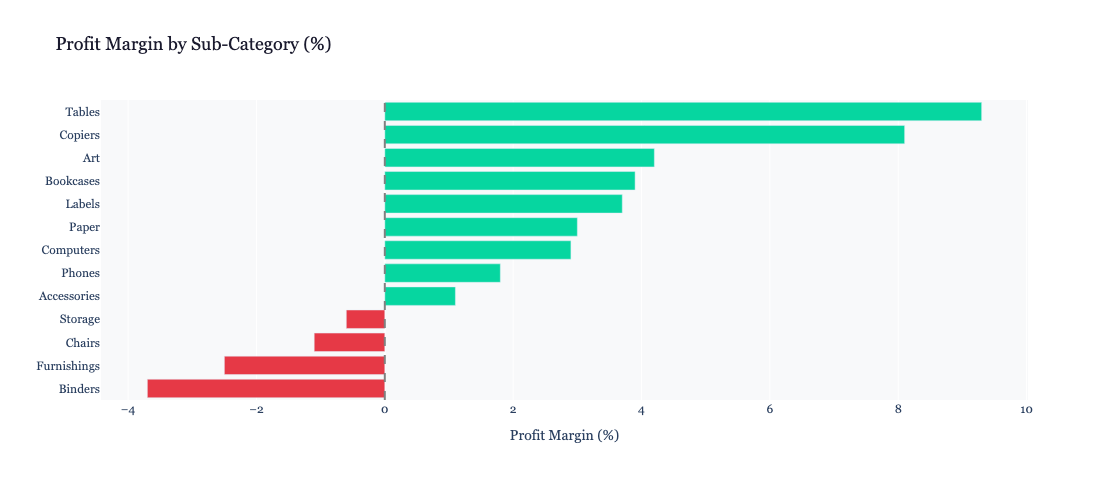

In [6]:
sub_perf = df.groupby('Sub-Category').agg(
    Sales=('Sales','sum'), Profit=('Profit','sum')
).reset_index()
sub_perf['Margin'] = (sub_perf['Profit'] / sub_perf['Sales'] * 100).round(1)
sub_perf = sub_perf.sort_values('Margin')

fig4 = go.Figure(go.Bar(
    x=sub_perf['Margin'], y=sub_perf['Sub-Category'],
    orientation='h',
    marker_color=['#e63946' if v < 0 else '#06d6a0' for v in sub_perf['Margin']],
    hovertemplate='<b>%{y}</b><br>Margin: %{x:.1f}%<extra></extra>'
))
fig4.update_layout(
    title=dict(text='Profit Margin by Sub-Category (%)', font=dict(size=18, color='#1a1a2e')),
    xaxis_title='Profit Margin (%)', yaxis_title='',
    plot_bgcolor='#f8f9fa', paper_bgcolor='white',
    height=480, font=dict(family='Georgia')
)
fig4.add_vline(x=0, line_color='gray', line_dash='dash')
fig4.show()

## 🚚 Chart 5 — Shipping Mode by Region (Stacked)

Stacked bar showing shipping preference per region. Toggle ship modes via legend.

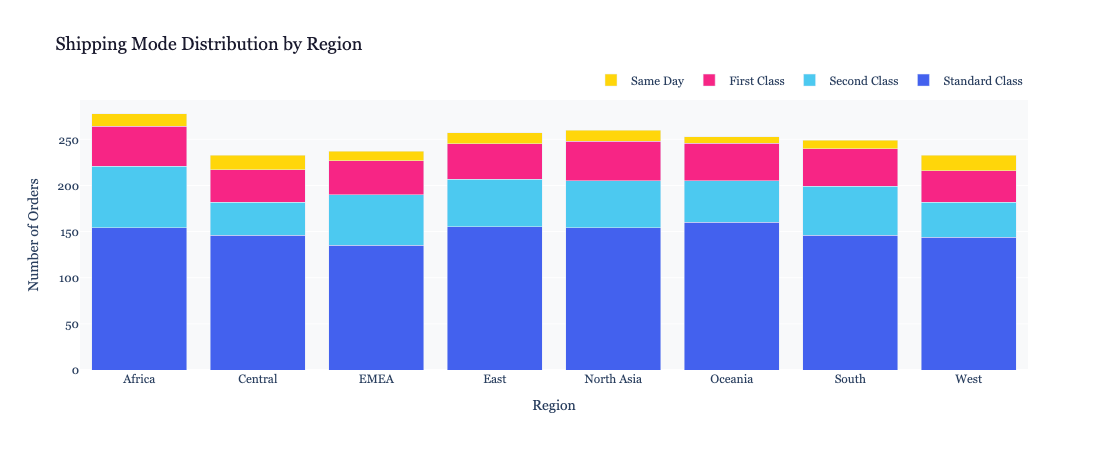

In [7]:
ship_reg = df.groupby(['Region','Ship Mode']).size().reset_index(name='Orders')
ship_colors = {
    'Standard Class':'#4361ee','Second Class':'#4cc9f0',
    'First Class':'#f72585','Same Day':'#ffd60a'
}

fig5 = go.Figure()
for mode in ships:
    d = ship_reg[ship_reg['Ship Mode'] == mode]
    fig5.add_trace(go.Bar(
        name=mode, x=d['Region'], y=d['Orders'],
        marker_color=ship_colors[mode],
        hovertemplate='<b>%{x}</b><br>' + mode + ': %{y} orders<extra></extra>'
    ))

fig5.update_layout(
    title=dict(text='Shipping Mode Distribution by Region', font=dict(size=18, color='#1a1a2e')),
    barmode='stack',
    xaxis_title='Region', yaxis_title='Number of Orders',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    plot_bgcolor='#f8f9fa', paper_bgcolor='white',
    height=450, font=dict(family='Georgia')
)
fig5.show()

In [8]:
import plotly.io as pio

with open('GlobalSuperstore_Dashboard.html', 'w') as f:
    f.write('<html><head><title>Global Superstore Dashboard</title></head><body>\n')
    f.write('<h1 style="font-family:Georgia;padding:20px">Global Superstore Dashboard</h1>\n')
    for i, fig in enumerate([fig1, fig2, fig3, fig4, fig5], 1):
        f.write(pio.to_html(fig, full_html=(i==1), include_plotlyjs=(i==1)))
        f.write('<br>\n')
    f.write('</body></html>')

print('HTML saved to Desktop!')

HTML saved to Desktop!


## 💡 Key Insights

1. **Technology dominates revenue** across all regions, but Office Supplies has surprisingly strong profit margins in some areas.
2. **Discounts above 30% almost always produce losses** — the scatter plot clearly shows profit turns negative beyond that threshold.
3. **Consumer segment leads in volume**, but Corporate segment shows more consistent month-over-month growth.
4. **Some sub-categories are chronic loss-makers** — identified in red on Chart 4 — worth reviewing pricing strategy.
5. **Standard Class shipping dominates** all regions (~60%), but Same Day usage is higher in Western regions.

---
*Dashboard built with Python + Plotly. Dataset: Global Superstore (Kaggle).*